In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

        width     length          price
Id                                     
1   12.914151  16.710240  313365.198594
2    8.880048  16.502571  248330.423075
3   14.251354  14.516700  261452.391633
4   14.821694  20.142415  401121.197063
5    6.146894  19.173231  212155.824231

Sebelum:
width     157
length    150
price       0
dtype: int64

Kita impute dulu ya guys yak

Sesudah:
width     0
length    0
price     0
dtype: int64


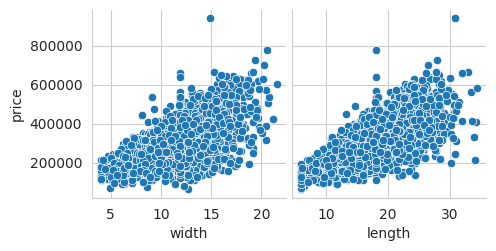

In [2]:
df = pd.read_csv("train.csv").set_index("Id")
print(df.head())

x_cols = df.columns[:-1]

print(f"\nSebelum:\n{df.isna().sum()}")

print("\nKita impute dulu ya guys yak\n")
df["width"] = df["width"].fillna(df["width"].mean())
df["length"] = df["length"].fillna(df["length"].mean())

print(f"Sesudah:\n{df.isna().sum()}")

sns.pairplot(data=df, x_vars=x_cols, y_vars="price")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X, y = df.iloc[:, :-1].to_numpy(), df.iloc[:, -1].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

print(X_train.shape)
print(X_test.shape)

(2400, 2)
(600, 2)


## Standar, tidak memakai PCA

Error RMSE: 42639.195546242845


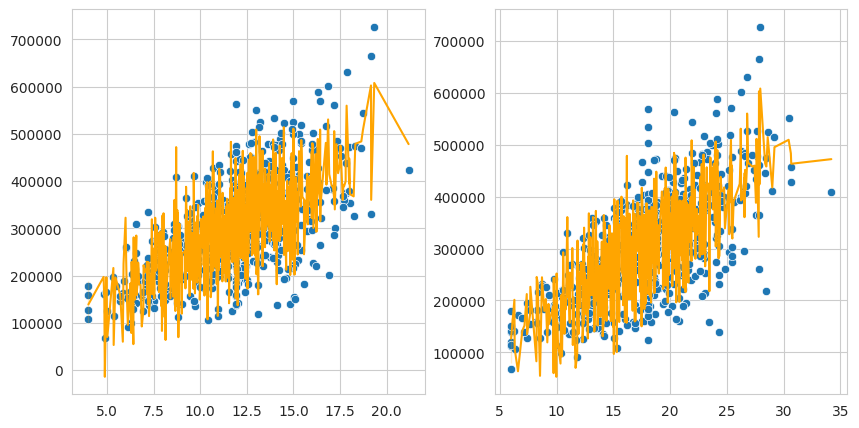

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipeline_no_pca = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

pipeline_no_pca.fit(X_train, y_train)

y_pred = pipeline_no_pca.predict(X_test)

print(f"Error RMSE: {np.sqrt(np.mean((y_test - y_pred) ** 2))}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(x=X_test[:, 0], y=y_test, ax=axes[0])
sns.lineplot(x=X_test[:, 0], y=y_pred, ax=axes[0], c="orange")
sns.scatterplot(x=X_test[:, 1], y=y_test, ax=axes[1])
sns.lineplot(x=X_test[:, 1], y=y_pred, ax=axes[1], c="orange")

plt.show()

## Memakai PCA

(600,)
(600,)
RMSE Error: 103573.50882588039


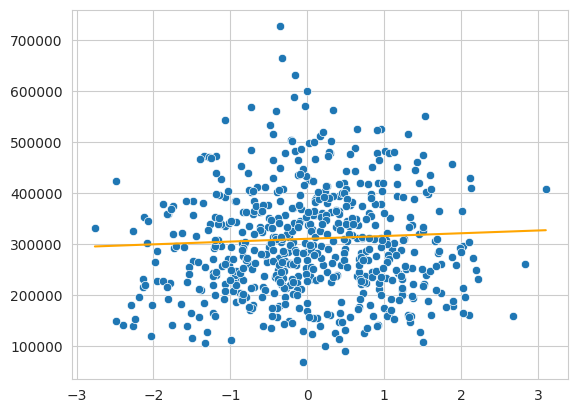

In [5]:
from sklearn.decomposition import PCA

pipeline_with_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=1),
    StandardScaler(),
    LinearRegression()    
)

pipeline_with_pca.fit(X_train, y_train)

y_pred = pipeline_with_pca.predict(X_test)
X_test_before_model = pipeline_with_pca[:-1].transform(X_test).flatten()

print(X_test_before_model.shape)
print(y_test.shape)

sns.scatterplot(x=X_test_before_model, y=y_test)
sns.lineplot(x=X_test_before_model, y=y_pred, c="orange")

print(f"RMSE Error: {np.sqrt(np.mean((y_test - y_pred) ** 2))}")

plt.show()

## Coba lagi pakai randomforestregressor

Error RMSE: 41987.78664392946


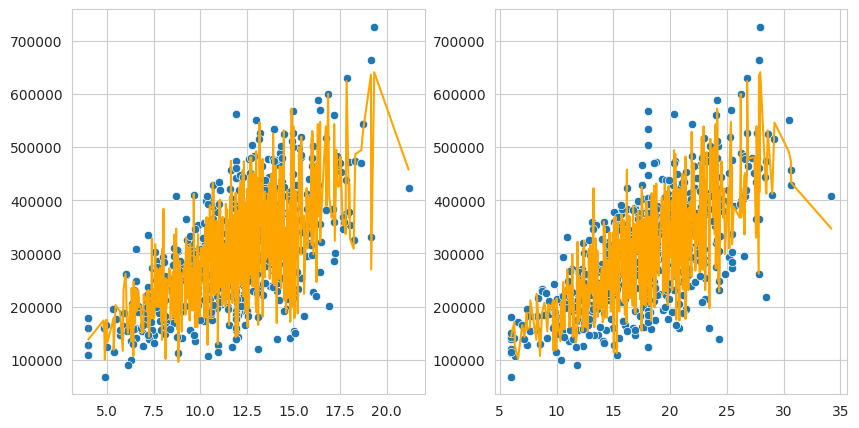

Kayaknya ini ovefitting


In [6]:
from sklearn.ensemble import RandomForestRegressor

pipeline_random_forest = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(n_estimators=6, random_state=67)
)

pipeline_random_forest.fit(X_train, y_train)

y_pred = pipeline_random_forest.predict(X_test)

print(f"Error RMSE: {np.sqrt(np.mean((y_test - y_pred) ** 2))}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(x=X_test[:, 0], y=y_test, ax=axes[0])
sns.lineplot(x=X_test[:, 0], y=y_pred, ax=axes[0], c="orange")
sns.scatterplot(x=X_test[:, 1], y=y_test, ax=axes[1])
sns.lineplot(x=X_test[:, 1], y=y_pred, ax=axes[1], c="orange")

plt.show()

print("Kayaknya ini ovefitting")

## Kita coba pakai feature engineering

RMSE Error: 38701.394016684775


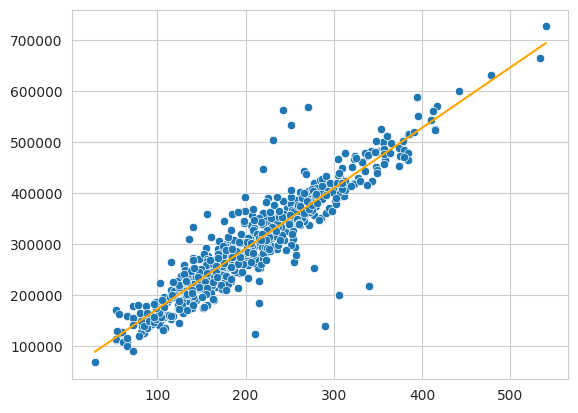

In [7]:
X_train_area = (X_train[:, 0] * X_train[:, 1]).reshape(-1, 1)
X_test_area = (X_test[:, 0] * X_test[:, 1]).reshape(-1, 1)

pipeline_feature_engineering = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

pipeline_feature_engineering.fit(X_train_area, y_train)

y_pred = pipeline_feature_engineering.predict(X_test_area)

sns.scatterplot(x=X_test_area[:, 0], y=y_test)
sns.lineplot(x=X_test_area[:, 0], y=y_pred, c="orange")

print(f"RMSE Error: {np.sqrt(np.mean((y_test - y_pred) ** 2))}")

## Kita coba lagi, pakai remove outlier, gokil

<Axes: ylabel='Count'>

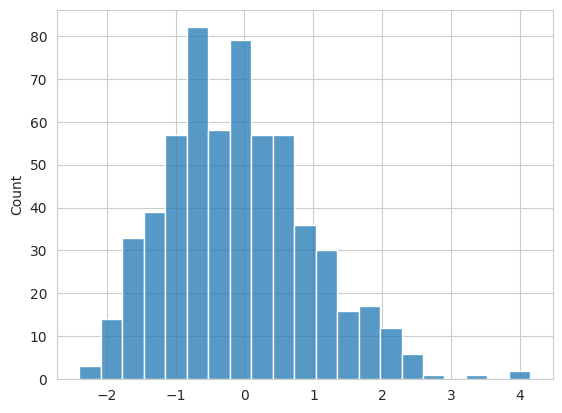

In [8]:
sns.histplot(x=pipeline_feature_engineering[:-1].transform(X_test_area).flatten())

Kayaknya outliernya ada di atas 3

RMSE Error: 39232.75766403509


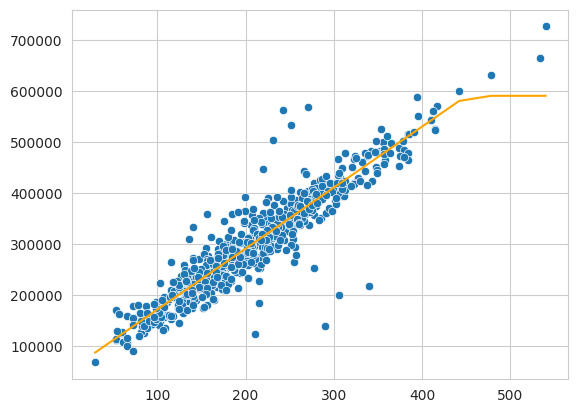

In [9]:
from sklearn.preprocessing import FunctionTransformer

X_train_area = (X_train[:, 0] * X_train[:, 1]).reshape(-1, 1)
X_test_area = (X_test[:, 0] * X_test[:, 1]).reshape(-1, 1)

pipeline_feature_engineering = make_pipeline(
    StandardScaler(),
    FunctionTransformer(lambda x: np.clip(x, np.min(x), 3)),
    LinearRegression()
)

pipeline_feature_engineering.fit(X_train_area, y_train)

y_pred = pipeline_feature_engineering.predict(X_test_area)

sns.scatterplot(x=X_test_area[:, 0], y=y_test)
sns.lineplot(x=X_test_area[:, 0], y=y_pred, c="orange")

print(f"RMSE Error: {np.sqrt(np.mean((y_test - y_pred) ** 2))}")

## Dari banyaknya insan di dunia, eh maksudnya model di dunia, aku pakai yang feature engineering aja

In [10]:
df_sub = pd.read_csv("test.csv").set_index("Id")

print(df_sub.isna().sum())

df_sub = df_sub.fillna(df_sub.mean())

print(f"\n{df_sub.isna().sum()}")

X_sub = df_sub.to_numpy()

X_sub_area = (X_sub[:, 0] * X_sub[:, 1]).reshape(-1, 1)

y_sub_pred = pipeline_feature_engineering.predict(X_sub_area)

sub_series = pd.Series(y_sub_pred, index=df_sub.index, name="price")
sub_series.head()

width     186
length    218
dtype: int64

width     0
length    0
dtype: int64


Id
3001    422211.620018
3002    458499.919702
3003    567174.798542
3004    190436.705427
3005    306046.491756
Name: price, dtype: float64

## Di-save ya guys yak

In [11]:
sub_series.to_csv("submission.csv")

## Versi 2: kita dropna

        width     length          price
Id                                     
1   12.914151  16.710240  313365.198594
2    8.880048  16.502571  248330.423075
3   14.251354  14.516700  261452.391633
4   14.821694  20.142415  401121.197063
5    6.146894  19.173231  212155.824231

Sebelum:
width     157
length    150
price       0
dtype: int64
Sesudah:
width     0
length    0
price     0
dtype: int64


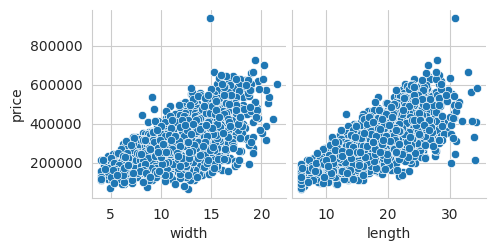

In [12]:
df = pd.read_csv("train.csv").set_index("Id")
print(df.head())

x_cols = df.columns[:-1]

print(f"\nSebelum:\n{df.isna().sum()}")

df = df.dropna()

print(f"Sesudah:\n{df.isna().sum()}")

sns.pairplot(data=df, x_vars=x_cols, y_vars="price")
plt.show()

In [13]:
X, y = df.iloc[:, :-1].to_numpy(), df.iloc[:, -1].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

print(X_train.shape)
print(X_test.shape)

(2162, 2)
(541, 2)


<Axes: ylabel='Count'>

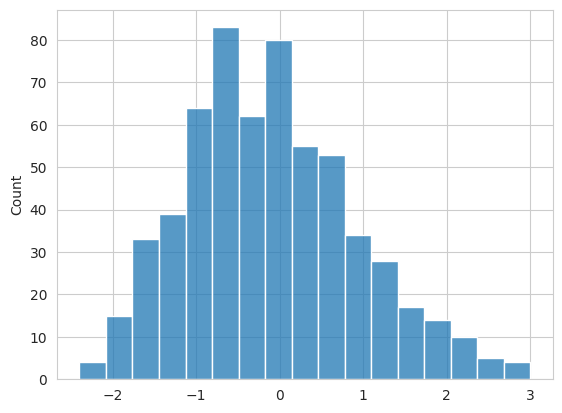

In [14]:
sns.histplot(x=pipeline_feature_engineering[:-1].transform(X_test_area).flatten())

RMSE Error: 26665.314849651368


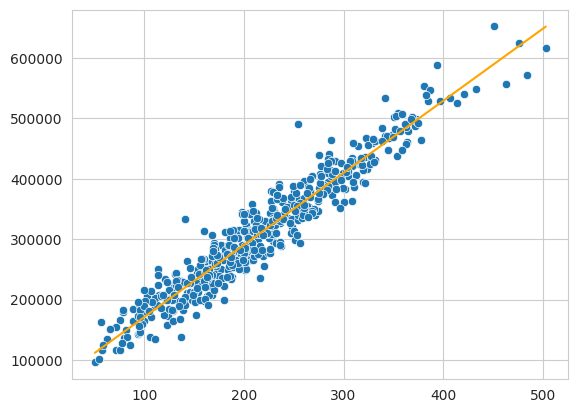

In [15]:
X_train_area = (X_train[:, 0] * X_train[:, 1]).reshape(-1, 1)
X_test_area = (X_test[:, 0] * X_test[:, 1]).reshape(-1, 1)

pipeline_feature_engineering = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

pipeline_feature_engineering.fit(X_train_area, y_train)

y_pred = pipeline_feature_engineering.predict(X_test_area)

sns.scatterplot(x=X_test_area[:, 0], y=y_test)
sns.lineplot(x=X_test_area[:, 0], y=y_pred, c="orange")

print(f"RMSE Error: {np.sqrt(np.mean((y_test - y_pred) ** 2))}")

## Kita coba urutkan dan ffill saja daripada impute mean, ya ampun

In [16]:
df_sub = pd.read_csv("test.csv").set_index("Id")

df_sub["area"] = df_sub["width"] * df_sub["length"]

print(df_sub.isna().sum())

og_index = df_sub.index
df_sub = df_sub.sort_values("area")
df_sub["area"] = df_sub["area"].ffill()
df_sub = df_sub.reindex(og_index)

# Sub area gokil

y_sub_pred = pipeline_feature_engineering.predict(X_sub_area)

sub_series = pd.Series(y_sub_pred, index=df_sub.index, name="price")
sub_series.head()

width     186
length    218
area      387
dtype: int64


Id
3001    421303.370759
3002    457518.848073
3003    565975.641124
3004    189993.575756
3005    305371.359515
Name: price, dtype: float64

In [17]:
sub_series.to_csv("submission.csv")